In [1]:
!hostname

n103.clstr


In [2]:
import pandas as pd 
import requests
import io
import numpy as np
import matplotlib.pyplot as plt
import glob
import xarray as xr
import geopandas as gpd
import matplotlib.colors as mcolors
import pandas as pd
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [3]:
winter_months = [11, 12, 1, 2, 3]

Alaska Shapefiles 
-

In [4]:
shapefile_path = "/center1/DYNDOWN/phutton5/ROS/boundaries/Alaska_Borough_and_Census_Area_Boundaries.shp"
borough_boundaries = gpd.read_file(shapefile_path)
borough_boundaries = borough_boundaries.set_crs(epsg=3338)
borough_boundaries = borough_boundaries.to_crs(epsg=4326)
FNSB_boundary = borough_boundaries[borough_boundaries['CommunityN'] == 'Fairbanks North Star Borough']
FNSB_geom = FNSB_boundary.geometry.iloc[0] 
FNSB_coords = []
FNSB_coords.extend(list(FNSB_geom.exterior.coords))
FNSB_coords = np.array(FNSB_coords)  
FNSB_coords = pd.DataFrame({
    "lon": FNSB_coords[:, 0],
    "lat": FNSB_coords[:, 1]})

Fairbanks_lat=(64.84)
Fairbanks_lon=(-147.72)

ASOS 
-

In [6]:
website='https://mesonet.agron.iastate.edu/cgi-bin/request/asos.py?network=AK_ASOS&station=PATK&data=p01m&data=wxcodes&data=metar&year1=1950&month1=10&day1=1&year2=2023&month2=3&day2=31&tz=Etc%2FUTC&format=onlycomma&latlon=yes&elev=no&missing=M&trace=T&direct=no&report_type=3&report_type=4'
response = requests.get(website)
if response.status_code == 200:
    data = io.StringIO(response.text)
    df = pd.read_csv(data, comment="#")  
    print(df.head())
else:
    print("Error:", response.status_code)

  station             valid      lon    lat p01m wxcodes  \
0    PATK  1950-10-01 00:00 -150.095  62.32    M       M   
1    PATK  1950-10-01 01:00 -150.095  62.32    M       M   
2    PATK  1950-10-01 02:00 -150.095  62.32    M       M   
3    PATK  1950-10-01 03:00 -150.095  62.32    M       M   
4    PATK  1950-10-01 04:00 -150.095  62.32    M       M   

                                               metar  
0  PATK 010000Z AUTO 60SM 11/06 RMK SLP163 T01110...  
1  PATK 010100Z AUTO 60SM 10/06 RMK SLP156 T01000...  
2  PATK 010200Z AUTO 40SM 10/06 RMK SLP152 T01000...  
3  PATK 010300Z AUTO 30SM 08/06 RMK SLP149 T00830...  
4  PATK 010400Z AUTO 15SM 07/05 RMK SLP146 T00720...  


In [7]:
df['valid'] = pd.to_datetime(df['valid'])
df['month'] = df['valid'].dt.month
df['date'] = df['valid'].dt.date
df['time'] = df['valid'].dt.time
#df['tmpc']
#df = df.drop(columns=['column_name'])
winter_df = df[df['month'].isin([11, 12, 1, 2, 3])] #filter to only keep the ROS months 

winter_df['date'] = pd.to_datetime(winter_df['date'])
year = winter_df['date'].dt.year
month = winter_df['date'].dt.month
season_start = year.where(~month.isin([1, 2, 3]), year - 1)
season_end = season_start + 1
winter_df['season'] = season_start.astype(str) + '-' + season_end.astype(str)

#filter to only when RA is present 
mask = winter_df['wxcodes'].str.contains('RA', na=False)
rain_and_mixed_df = winter_df[mask]
rain_and_mixed_df['p01m'] = rain_and_mixed_df['p01m'].replace('M', np.nan) 
rain_and_mixed_df['p01m'] = rain_and_mixed_df['p01m'].replace('T', 0.001) 
rain_and_mixed_df['p01m'] = pd.to_numeric(rain_and_mixed_df['p01m'], errors='coerce')

/center1/DYNDOWN/phutton5/VSCODE_dump/ipykernel_1982879/1912088275.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  winter_df['date'] = pd.to_datetime(winter_df['date'])
/center1/DYNDOWN/phutton5/VSCODE_dump/ipykernel_1982879/1912088275.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  winter_df['season'] = season_start.astype(str) + '-' + season_end.astype(str)
/center1/DYNDOWN/phutton5/VSCODE_dump/ipykernel_1982879/1912088275.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a

In [42]:
monthly_order = [11, 12, 1, 2, 3]

seasonal_sum_rain_and_mixed_df = (rain_and_mixed_df.groupby('season')['p01m'].sum())
monthly_sum_by_season_ASOS = (rain_and_mixed_df.groupby(['month'])['p01m'].sum()) 
monthly_sum_by_season_ASOS=monthly_sum_by_season_ASOS.loc[monthly_order]

monthly_mean_by_season_ASOS = rain_and_mixed_df.groupby(['season'])['p01m'].mean()

start_years = seasonal_sum_rain_and_mixed_df.index.str.slice(0, 4).astype(int)
all_seasons = [f"{y}-{y+1}" for y in range(start_years.min(), start_years.max() + 1)]

seasonal_sum_rain_and_mixed_df = seasonal_sum_rain_and_mixed_df.reindex(all_seasons)
seasonal_sum_rain_and_mixed_df=seasonal_sum_rain_and_mixed_df.fillna(0)
seasons_seasonal_sum_rain_and_mixed_df = seasonal_sum_rain_and_mixed_df.index.tolist()

#Rain only, no other precip, not realistic max of 2mm 
'''
mask = winter_df['wxcodes'].str.fullmatch(r'[-+]?(SH)?RA') #matches 'RA' or '-RA' and SH RA
rain_only_df = winter_df[mask]
rain_only_df['p01m'] = rain_only_df['p01m'].replace(['M', 'T'], np.nan)
rain_only_df['p01m'] = pd.to_numeric(rain_only_df['p01m'], errors='coerce') # Convert to numeric (float)

seasonal_sum_rain_only_df = (rain_only_df.loc[rain_only_df['p01m'] >= 0.254].groupby('season')['p01m'].sum())
#seasonal_sum_rain_only_df=rain_only_df.groupby('season')['p01m'].sum()
seasonal_sum_rain_only_df = seasonal_sum_rain_only_df.reindex(all_seasons)
seasonal_sum_rain_only_df=seasonal_sum_rain_only_df.fillna(0)
seasons_seasonal_sum_rain_df = seasonal_sum_rain_only_df.index.tolist()
'''

"\nmask = winter_df['wxcodes'].str.fullmatch(r'[-+]?(SH)?RA') #matches 'RA' or '-RA' and SH RA\nrain_only_df = winter_df[mask]\nrain_only_df['p01m'] = rain_only_df['p01m'].replace(['M', 'T'], np.nan)\nrain_only_df['p01m'] = pd.to_numeric(rain_only_df['p01m'], errors='coerce') # Convert to numeric (float)\n\nseasonal_sum_rain_only_df = (rain_only_df.loc[rain_only_df['p01m'] >= 0.254].groupby('season')['p01m'].sum())\n#seasonal_sum_rain_only_df=rain_only_df.groupby('season')['p01m'].sum()\nseasonal_sum_rain_only_df = seasonal_sum_rain_only_df.reindex(all_seasons)\nseasonal_sum_rain_only_df=seasonal_sum_rain_only_df.fillna(0)\nseasons_seasonal_sum_rain_df = seasonal_sum_rain_only_df.index.tolist()\n"

In [43]:
filtered_rain_and_mixed_df = rain_and_mixed_df[(rain_and_mixed_df['p01m'].notna()) & (rain_and_mixed_df['p01m'] != 0)]
filtered_rain_and_mixed_df=(filtered_rain_and_mixed_df.groupby(['season', 'month'])['p01m'].sum().reset_index())

p90 = filtered_rain_and_mixed_df['p01m'].quantile(0.90)
p95 = filtered_rain_and_mixed_df['p01m'].quantile(0.95)
p75 = filtered_rain_and_mixed_df['p01m'].quantile(0.75)
p80 = filtered_rain_and_mixed_df['p01m'].quantile(0.80)
p50 = filtered_rain_and_mixed_df['p01m'].quantile(0.5)
print(p50, p75, p80, p90, p95)
#filtered_greatherthan_01_rain_and_mixed_df=filtered_rain_and_mixed_df[filtered_rain_and_mixed_df['p01m'] > 2.54]

filtered_90percentile_rain_and_mixed_df=filtered_rain_and_mixed_df[filtered_rain_and_mixed_df['p01m'] > p90]
filtered_90percentile_rain_and_mixed_df

3.043 15.7185 23.03180000000002 46.3536 53.52869999999999


,season,month,p01m
9,1999-2000,12,53.080
19,2002-2003,2,171.568
20,2002-2003,3,54.853
27,2004-2005,1,46.965
40,2008-2009,1,49.779
48,2010-2011,11,47.752
52,2012-2013,1,49.744
55,2013-2014,1,69.080
67,2015-2016,3,54.362
68,2015-2016,11,61.398


In [34]:
seasonal_sum_rain_and_mixed_df = (rain_and_mixed_df.groupby('season')['p01m'].sum())
monthly_sum_ASOS = (rain_and_mixed_df.groupby(['month'])['p01m'].sum())
monthly_sum_ASOS=monthly_sum_ASOS.reindex(winter_months).values 

monthly_mean_by_season_ASOS = (rain_and_mixed_df.groupby(['season', 'month'])['p01m'].mean().unstack('month'))

start_years = seasonal_sum_rain_and_mixed_df.index.str.slice(0, 4).astype(int)
all_seasons = [f"{y}-{y+1}" for y in range(start_years.min(), start_years.max() + 1)]

seasonal_sum_rain_and_mixed_df = seasonal_sum_rain_and_mixed_df.reindex(all_seasons)
#seasonal_sum_rain_and_mixed_df=seasonal_sum_rain_and_mixed_df.fillna(0)
seasons_seasonal_sum_rain_and_mixed_df = seasonal_sum_rain_and_mixed_df.index.tolist()



Plotting
-

To Compare PAFA, DYN and RAW
-


In [35]:
panc_lat=62.32
panc_lon=-150.0950

#selected values later are 61.183758 -149.99158

In [36]:
def getXY(lat, lon, dataarray):
    abslat = np.abs(dataarray.XLAT-lat)
    abslon = np.abs(dataarray.XLONG-lon)
    d = abslon**2 + abslat**2
    flat_index = np.argmin(d.values)
    yloc, xloc = np.unravel_index(flat_index, d.shape)
    return xloc, yloc

def getXY_latlon(lat, lon, dataarray):
    abslat = np.abs(dataarray.latitude - lat)
    abslon = np.abs(dataarray.longitude - lon)
    d = abslon**2 + abslat**2
    flat_index = np.argmin(d.values)
    yloc, xloc = np.unravel_index(flat_index, d.shape)
    return xloc, yloc

In [37]:
regridded_era5_path='/center1/DYNDOWN/phutton5/ROS/All_of_AK/All_of_AK_netcdf_files/ERA5_31kmto4km_nearest_regridded.nc'
regridded_era5=xr.open_dataset(regridded_era5_path)

#ERA5  4km
era5_4km='/center1/DYNDOWN/phutton5/ROS/All_of_AK/All_of_AK_netcdf_files/ROS_Monthly_*.nc'
era5_4km = xr.open_mfdataset(era5_4km,combine="by_coords", parallel=True)


In [38]:
x_idx, y_idx = getXY(panc_lat, panc_lon, regridded_era5)
nearest_lat = regridded_era5.XLAT[y_idx, x_idx]
nearest_lon = regridded_era5.XLONG[y_idx, x_idx]


In [48]:
cell = era5_4km.isel(
    south_north=y_idx,
    west_east=x_idx
)

In [49]:
era5_4km_rain_sum_at_site = era5_4km['rain_sum'].isel(south_north=y_idx,west_east=x_idx)
seasonal_rain_sum_at_site_era5_4km=era5_4km_rain_sum_at_site.sum(dim='month')
monthly_rain_sum_at_site_era5_4km=era5_4km_rain_sum_at_site.sum(dim='season')
#monthly_rain_MEAN_at_site_era5_4km=era5_4km['rain_ros_sum'].isel(south_north=y_idx,west_east=x_idx).groupby('month','season').mean()


era5_regridded_31km_rain_sum_at_site = regridded_era5['rain_sum'].isel(south_north=y_idx,west_east=x_idx)
seasonal_rain_sum_at_site_era5_regridded_31km=era5_regridded_31km_rain_sum_at_site.sum(dim='month')
monthly_rain_sum_at_site_era5_regridded_31km=era5_regridded_31km_rain_sum_at_site.sum(dim='season')

#monthly_rain_MEAN_at_site_era5_regridded_31km=regridded_era5['rain_ros_sum'].isel(south_north=y_idx,west_east=x_idx).groupby('month').mean()

seasons=era5_4km['season']

In [50]:
# 4km ERA5 as DataFrame
era5_4km_df = era5_4km_rain_sum_at_site.to_dataframe().reset_index()
era5_31km_df = era5_regridded_31km_rain_sum_at_site.to_dataframe().reset_index() 
era5_4km_monthly = era5_4km_df.groupby(['season', 'month'])['rain_sum'].sum().reset_index()
era5_31km_monthly = era5_31km_df.groupby(['season', 'month'])['rain_sum'].sum().reset_index()

top_rain_df = filtered_90percentile_rain_and_mixed_df.copy()

top_rain_df = top_rain_df.merge(
    era5_4km_monthly,
    on=['season', 'month'],
    how='left'
).rename(columns={'rain_sum':'ERA5_4km_mm'})

top_rain_df = top_rain_df.merge(
    era5_31km_monthly,
    on=['season', 'month'],
    how='left'
).rename(columns={'rain_sum':'ERA5_31km_mm'})

top_rain_df

,season,month,p01m,ERA5_4km_mm,ERA5_31km_mm
0,1999-2000,12,53.080,70.918106,17.295278
1,2002-2003,2,171.568,100.573975,45.629372
2,2002-2003,3,54.853,21.002789,10.463962
3,2004-2005,1,46.965,37.887211,3.732408
4,2008-2009,1,49.779,38.014221,23.432568
5,2010-2011,11,47.752,77.779625,17.986990
6,2012-2013,1,49.744,52.115547,16.677109
7,2013-2014,1,69.080,74.867905,41.664661
8,2015-2016,3,54.362,47.414619,27.356442
9,2015-2016,11,61.398,75.522125,21.583146


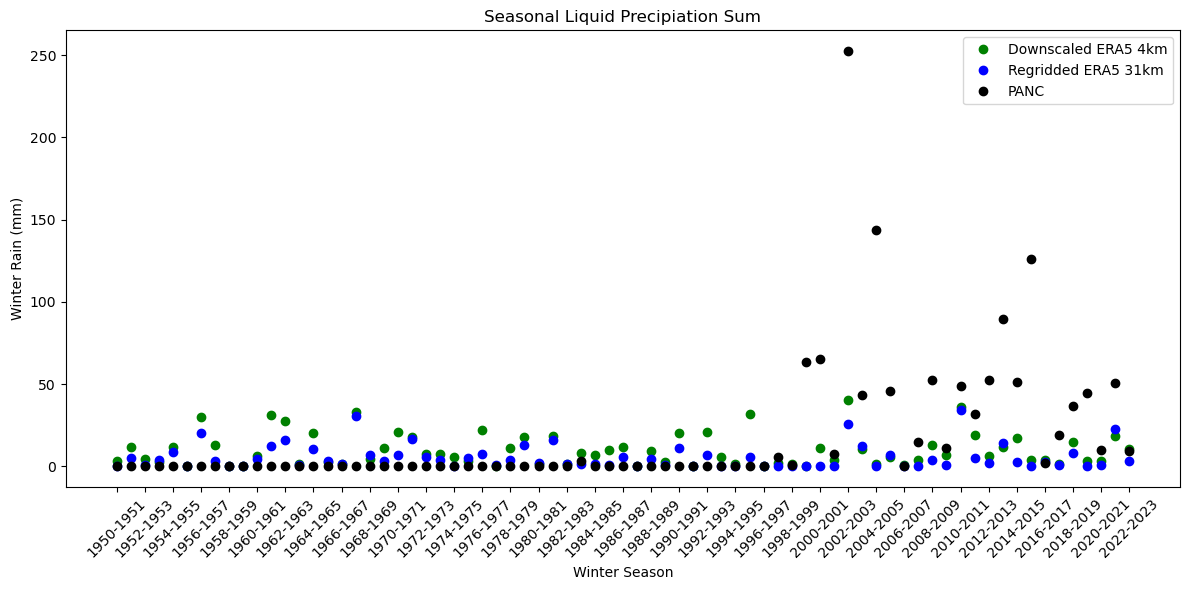

In [24]:
plt.figure(figsize=(12, 6))
#seasonal_rain_sum_at_site_era5_4km
#seasonal_rain_sum_at_site_era5_regridded_31km
#plt.plot(rick_season_full_df['season'],rick_season_full_df['season_sum_rain_mm'], marker='*',markersize=10, linestyle='', color='purple',label='Local Dataset',zorder=10)
plt.plot(seasons,seasonal_rain_sum_at_site_era5_4km, marker='o',label='Downscaled ERA5 4km', linestyle='', color='green')
plt.plot(seasons,seasonal_rain_sum_at_site_era5_regridded_31km, marker='o', label='Regridded ERA5 31km', linestyle='', color='blue')
plt.plot(seasons_seasonal_sum_rain_and_mixed_df,seasonal_sum_rain_and_mixed_df, label='PANC',marker='o', linestyle='', color='black')
plt.gca().patch.set_alpha(0.0)
plt.title('Seasonal Liquid Precipiation Sum')
plt.xlabel('Winter Season')
plt.ylabel('Winter Rain (mm)')
plt.xticks(ticks=range(0, len(seasons_seasonal_sum_rain_and_mixed_df), 2),labels=seasons_seasonal_sum_rain_and_mixed_df[::2],rotation=45) 
plt.legend()
plt.tight_layout()
plt.show()

In [25]:
top_rain_df

,season,month,p01m,ERA5_4km_mm,ERA5_31km_mm
0,1999-2000,12,53.080,0.263164,0.196750
1,2000-2001,11,38.393,8.519563,0.389776
2,2002-2003,2,171.568,18.546921,14.560307
3,2002-2003,3,54.853,6.923274,7.681128
4,2003-2004,11,42.363,10.391039,12.133719
5,2004-2005,1,46.965,1.720950,0.000000
6,2004-2005,3,44.927,0.000000,0.191763
7,2004-2005,11,39.930,0.000000,0.000000
8,2008-2009,1,49.779,9.349577,3.892048
9,2010-2011,11,47.752,35.691414,34.524695


NameError: name 'monthly_rain_MEAN_at_site_era5_4km' is not defined

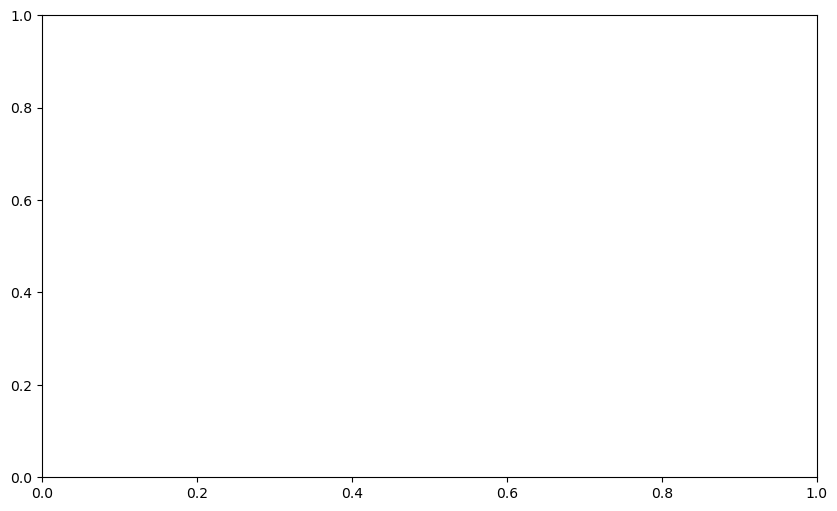

In [26]:


winter_months = [11, 12, 1, 2, 3]          # months in winter
month_labels = ['Nov', 'Dec', 'Jan', 'Feb', 'Mar']
width = 0.2

x = np.arange(len(winter_months))  # [0,1,2,3,4]
fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(x - width, monthly_rain_MEAN_at_site_era5_4km, width, color='green', label='Downscaled ERA5 4km')
ax.bar(x, monthly_rain_MEAN_at_site_era5_regridded_31km, width, color='blue', label='Regridded ERA5 31km')
ax.bar(x + width, monthly_mean_by_season_ASOS, width, color='black', label='Station Data PANC')

ax.set_xticks(x)
ax.set_xticklabels(month_labels)
ax.set_ylabel('Precipitation (mm)')
ax.set_title('Winter Monthly Liquid Precipitation MEAN (Nov–Mar)')
ax.legend()
fig.patch.set_alpha(0.0)
plt.tight_layout()
plt.show()

/center1/DYNDOWN/phutton5/VSCODE_dump/ipykernel_1982879/1400723049.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(


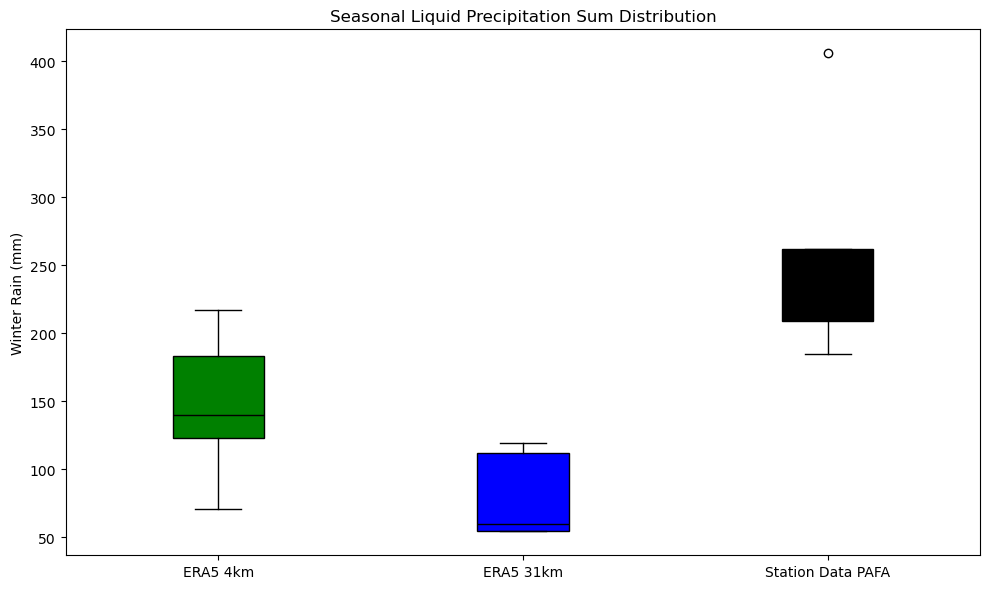

In [27]:
plt.figure(figsize=(10, 6))

data = [
    monthly_rain_sum_at_site_era5_4km.values.flatten(),
    monthly_rain_sum_at_site_era5_regridded_31km.values.flatten(),
    monthly_sum_by_season_ASOS.values.flatten()
]

# Remove NaNs (important!)
data = [d[~np.isnan(d)] for d in data]

labels = ['ERA5 4km', 'ERA5 31km', 'Station Data PAFA']
colors = ['green', 'blue', 'black']

bp = plt.boxplot(
    data,
    labels=labels,
    patch_artist=True,
    medianprops=dict(color='black')
)

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

plt.title('Seasonal Liquid Precipitation Sum Distribution')
plt.ylabel('Winter Rain (mm)')
plt.tight_layout()
plt.show()


All Rain in The months not just when snow is on the ground 
-

In [29]:
allrain_era5_4km_rain_sum_at_site = era5_4km['rain_sum'].isel(south_north=x_idx,west_east=y_idx)
allrain_monthly_rain_sum_at_site_era5_4km=allrain_era5_4km_rain_sum_at_site.sum(dim='season')

allrain_era5_regridded_31km_rain_sum_at_site = regridded_era5['rain_sum'].isel(south_north=x_idx,west_east=y_idx)
allrain_monthly_rain_sum_at_site_era5_regridded_31km=era5_regridded_31km_rain_sum_at_site.sum(dim='season')


In [30]:
monthly_sum_by_season_ASOS

month
11    406.045
12    185.219
1     262.454
2     218.990
3     208.808
Name: p01m, dtype: float64

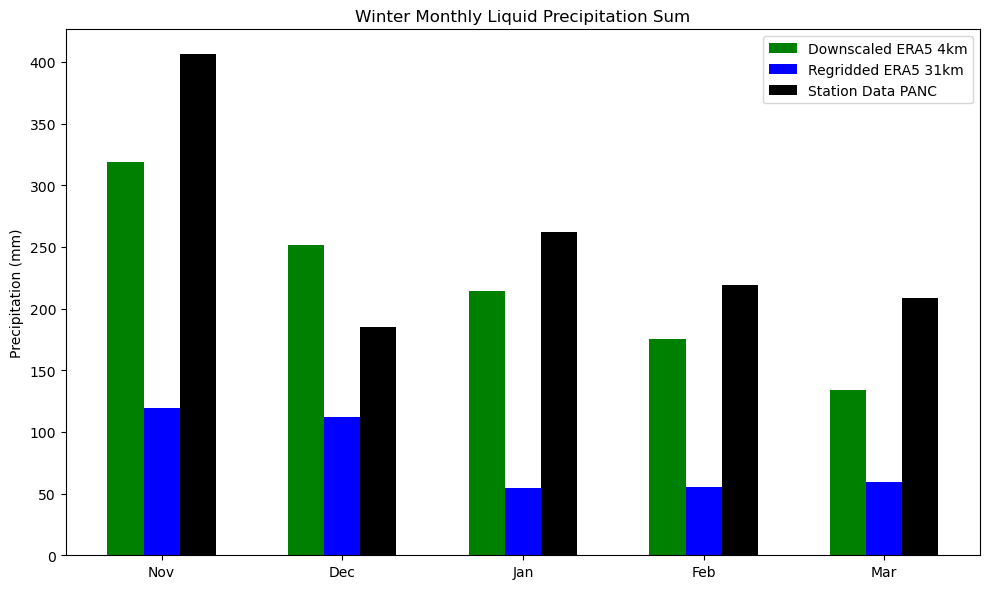

In [31]:
winter_months = [11, 12, 1, 2, 3]          # months in winter
month_labels = ['Nov', 'Dec', 'Jan', 'Feb', 'Mar']
width = 0.2

x = np.arange(len(winter_months))  # [0,1,2,3,4]
fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(x - width, allrain_monthly_rain_sum_at_site_era5_4km, width, color='green', label='Downscaled ERA5 4km')
ax.bar(x, allrain_monthly_rain_sum_at_site_era5_regridded_31km, width, color='blue', label='Regridded ERA5 31km')
ax.bar(x + width, monthly_sum_by_season_ASOS, width, color='black', label='Station Data PANC')

ax.set_xticks(x)
ax.set_xticklabels(month_labels)
ax.set_ylabel('Precipitation (mm)')
ax.set_title('Winter Monthly Liquid Precipitation Sum')
ax.legend()
fig.patch.set_alpha(0.0)
plt.tight_layout()
plt.show()